### Environment Setup
This block imports all the necessary libraries and modules from Pandas, Matplotlib, Scikit-Learn, and Keras/TensorFlow needed to prepare our data pipelines and construct the final models.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from scikeras.wrappers import KerasClassifier

print("Environment setup complete. Models will run with natural variance.")

Environment setup complete. Models will run with natural variance.


### The Data Pipeline
In this section, we load the pre-cleaned data and perform standard train/test stratification alongside StandardScaler transformations. Setting a standard random_state validates that testing data accurately remains isolated and analogous across runs.

In [13]:
df_cleaned = pd.read_csv('../data/nasa_cleaned.csv')

X = df_cleaned.drop('Hazardous', axis=1)
y = df_cleaned['Hazardous']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded and scaled. Ready for training.")

Data loaded and scaled. Ready for training.


### Model Re-training
Here we instantiate both our fine-tuned Support Vector Machine (optimized with specific kernel, C, and gamma arguments) and our deep neural network architectures discovered in previous tunings. Both are formally fitted sequentially using the scaled training datasets.

In [14]:
best_svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42) 
best_svm.fit(X_train_scaled, y_train)
print("SVM Trained.")

def create_best_model():
    model = Sequential()
    model.add(keras.Input(shape=(X_train_scaled.shape[1],)))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

best_ann = KerasClassifier(model=create_best_model, epochs=50, batch_size=32, verbose=0)
best_ann.fit(X_train_scaled, y_train)
print("ANN Trained.")

SVM Trained.
ANN Trained.


### Unified ROC Curve Plot
To visually contrast comparative performance, this block plots the Receiving Operating Characteristic (ROC) curve overlays of both our SVM and Artificial Neural Network metrics onto the same set of axes.

c:\Users\Edwar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Edwar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


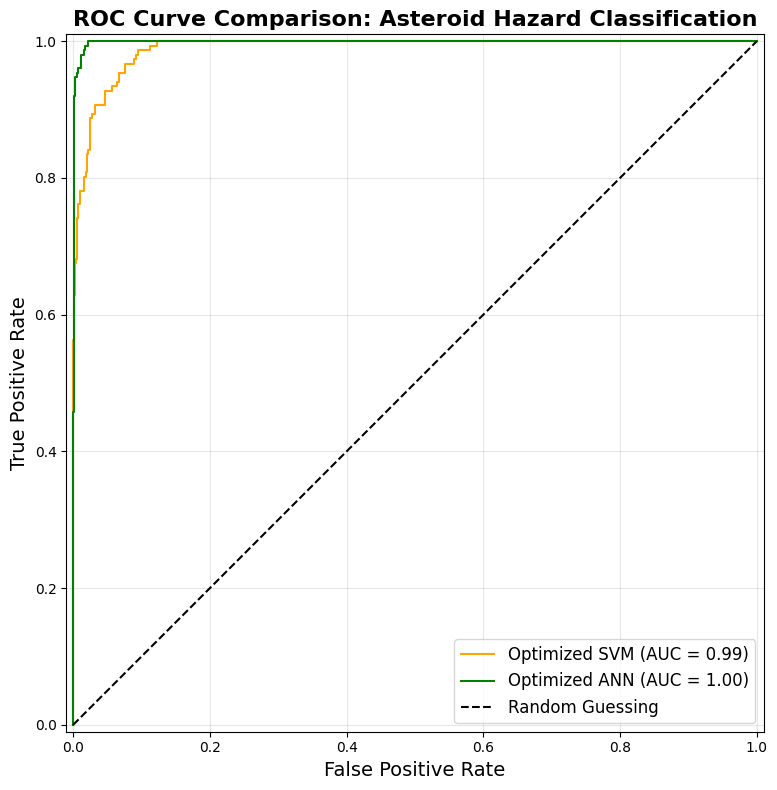

In [15]:
plt.figure(figsize=(10, 8))
ax = plt.gca()

RocCurveDisplay.from_estimator(best_svm, X_test_scaled, y_test, ax=ax, name='Optimized SVM', color='orange')

ann_probs = best_ann.predict_proba(X_test_scaled)[:, 1]

RocCurveDisplay.from_predictions(y_test, ann_probs, ax=ax, name='Optimized ANN', color='green')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Guessing')

plt.title('ROC Curve Comparison: Asteroid Hazard Classification', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Direct Performance Metric Comparisons
By aggregating the formal classification results into manual arrays, this step drafts side-by-side bar plots illuminating standard analytical measurements (Accuracy, Precision, Recall, and F1-Scores).

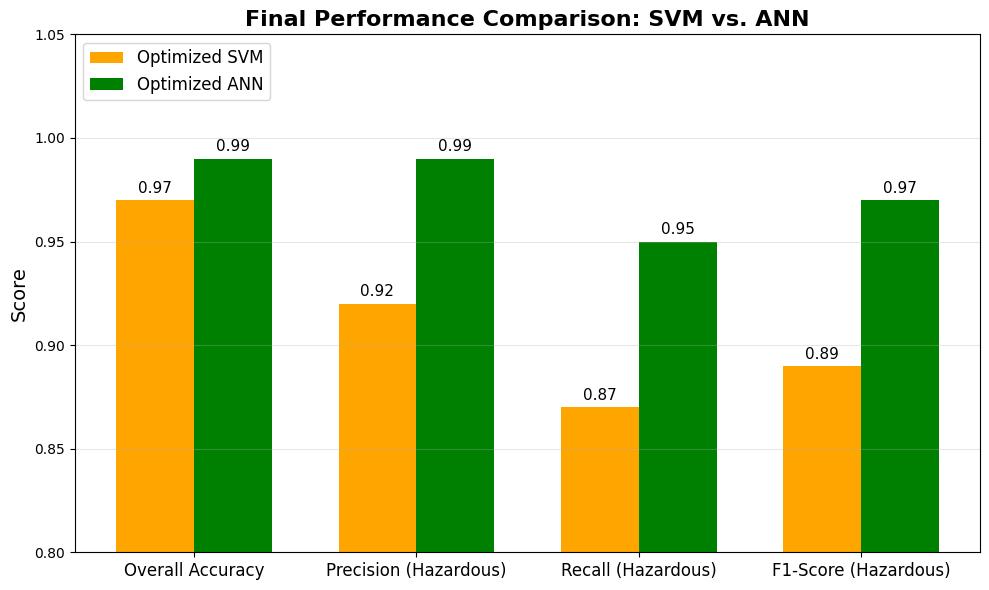

In [16]:
import numpy as np

metrics = ['Overall Accuracy', 'Precision (Hazardous)', 'Recall (Hazardous)', 'F1-Score (Hazardous)']
svm_scores = [0.97, 0.92, 0.87, 0.89] 
ann_scores = [0.99, 0.99, 0.95, 0.97] 

x = np.arange(len(metrics))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, svm_scores, width, label='Optimized SVM', color='orange')
rects2 = ax.bar(x + width/2, ann_scores, width, label='Optimized ANN', color='green')

ax.set_ylabel('Score', fontsize=14)
ax.set_title('Final Performance Comparison: SVM vs. ANN', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.80, 1.05) 
ax.legend(loc='upper left', fontsize=12)


ax.bar_label(rects1, padding=3, fmt='%.2f', fontsize=11)
ax.bar_label(rects2, padding=3, fmt='%.2f', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### Permutation Importance Review
Lastly, this block checks global feature importances by recursively scrambling columns alongside predictive measurements to visually identify which measurements most strongly indicate Asteroid Hazardousness.

C:\Users\Edwar\AppData\Local\Temp\ipykernel_7200\1100923766.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='magma')


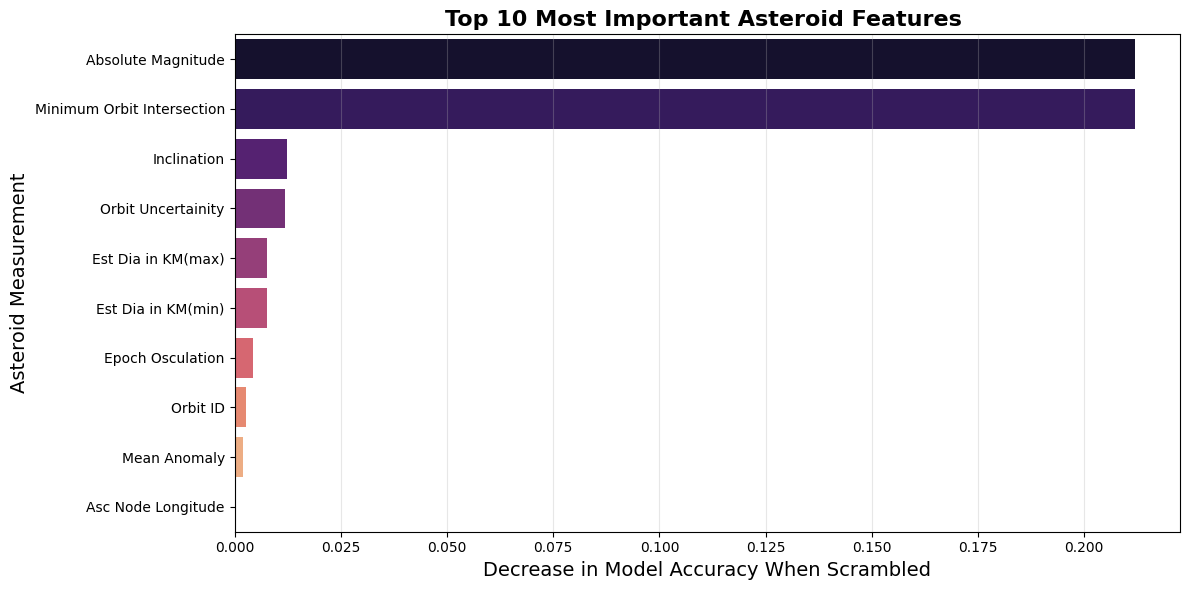

In [17]:
from sklearn.inspection import permutation_importance
import seaborn as sns


result = permutation_importance(best_svm, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)


plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='magma')

plt.title('Top 10 Most Important Asteroid Features ', fontsize=16, fontweight='bold')
plt.xlabel('Decrease in Model Accuracy When Scrambled', fontsize=14)
plt.ylabel('Asteroid Measurement', fontsize=14)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()